# লিনিয়ার রিগ্রেশন**গল্প: সরলরেখা দিয়ে ডেটা ব্যাখ্যা করা**কল্পনা করো তুমি বন্ধুদের বয়স (X) আর তাদের উচ্চতা (y) মাপছ। একটি সরলরেখা এঁকে তুমি বলতে পারো: 'যদি বয়স X হয়, তাহলে উচ্চতা হবে প্রায় y!'লিনিয়ার রিগ্রেশন ডেটার মধ্যে একটি সরলরেখা (বা সমতল) খুঁজে বের করে যা সবচেয়ে ভালোভাবে ডেটা ব্যাখ্যা করে।

## আমরা কী শিখব?1. লিনিয়ার রিগ্রেশন (LinearRegression)2. রিজ রিগ্রেশন (Ridge - L2 নিয়মিতকরণ)3. লাসো রিগ্রেশন (Lasso - L1 নিয়মিতকরণ)4. Coefficient (সহগ) ব্যাখ্যা5. R^2 স্কোর দিয়ে মডেল মূল্যায়ন

## প্রথমে লাইব্রেরি ইম্পোর্ট করি

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
print('লাইব্রেরি ইম্পোর্ট সফল হয়েছে!')

লাইব্রেরি ইম্পোর্ট সফল হয়েছে!


## কৃত্রিম ডেটা তৈরি করাmake_regression দিয়ে একটি সরল ডেটাসেট তৈরি করি।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: Use

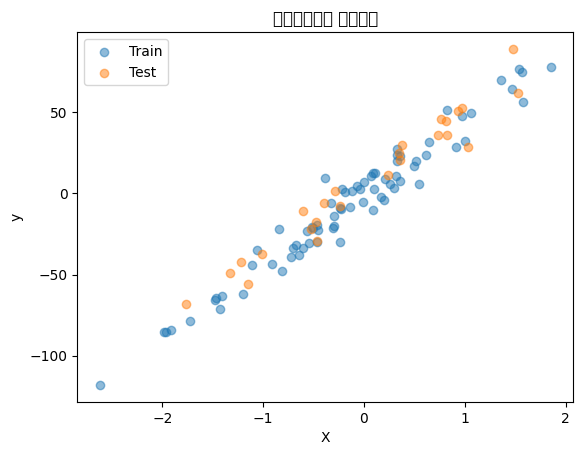

In [2]:
X, y, coef = make_regression(n_samples=100, n_features=1,
                             noise=10, coef=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)
plt.scatter(X_train, y_train, alpha=0.5, label='Train')
plt.scatter(X_test, y_test, alpha=0.5, label='Test')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('আমাদের ডেটা')
plt.show()

## লিনিয়ার রিগ্রেশন মডেলএকটি সরলরেখা ডেটার সাথে ফিট করি এবং coefficient দেখি।

Coefficient (ঢাল): 44.35589530093708
Intercept (ছেদ): -0.3985455467987773
R^2 স্কোর: 0.9311342838043285


C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: User

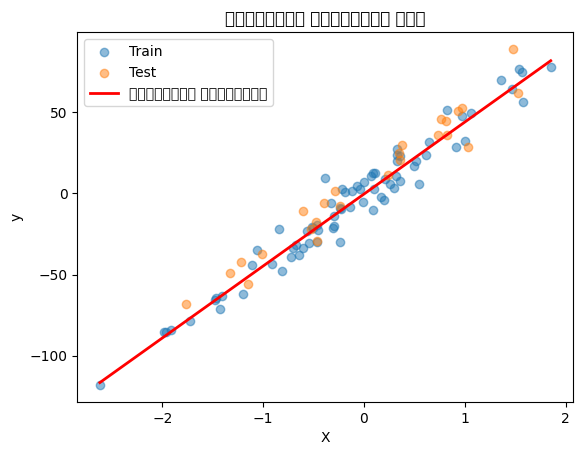

In [3]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print('Coefficient (ঢাল):', lr.coef_[0])
print('Intercept (ছেদ):', lr.intercept_)
print('R^2 স্কোর:', r2_score(y_test, y_pred))
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = lr.predict(X_line)
plt.scatter(X_train, y_train, alpha=0.5, label='Train')
plt.scatter(X_test, y_test, alpha=0.5, label='Test')
plt.plot(X_line, y_line, 'r-', linewidth=2, label='লিনিয়ার রিগ্রেশন')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.title('লিনিয়ার রিগ্রেশন ফিট')
plt.show()

## Coefficient ব্যাখ্যাCoefficient (সহগ) প্রতিটি feature-এর গুরুত্ব বোঝায়।- ধনাত্মক coefficient: feature বাড়লে target বাড়ে- ঋণাত্মক coefficient: feature বাড়লে target কমেCoefficient এর মান বোঝায় X 1 একক বাড়লে target কত একক বাড়ে।

## রিজ (Ridge) রিগ্রেশনRidge L2 নিয়মিতকরণ যোগ করে। এটি coefficient-এর মান ছোট রাখে, যা overfitting কমায়।alpha প্যারামিটার নিয়ন্ত্রণ করে কতটা নিয়মিতকরণ হবে।

In [4]:
X_multi, y_multi = make_regression(n_samples=100, n_features=10,
                                   noise=15, random_state=42)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_multi, y_multi, random_state=42)
lr_multi = LinearRegression()
lr_multi.fit(Xm_train, ym_train)
ridge = Ridge(alpha=1.0)
ridge.fit(Xm_train, ym_train)
print('LinearRegression R^2:', lr_multi.score(Xm_test, ym_test))
print('Ridge R^2:', ridge.score(Xm_test, ym_test))

LinearRegression R^2: 0.9941959730495544
Ridge R^2: 0.9934915888459592


## রিজ-এর alpha প্যারামিটারalpha-র মান বাড়ালে নিয়মিতকরণ বাড়ে, coefficient আরও ছোট হয়।

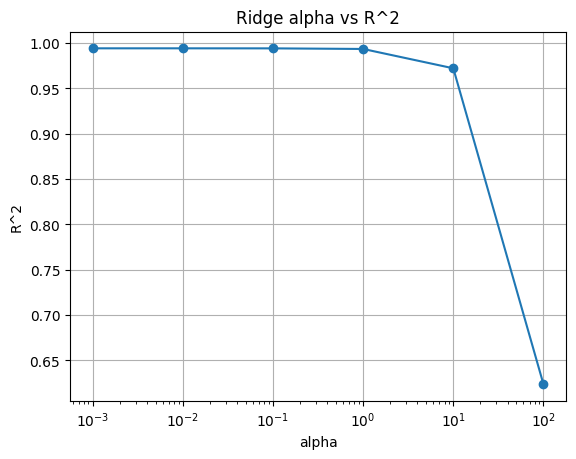

ছোট alpha: বেশি জটিল, বড় alpha: বেশি সরল


In [5]:
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
ridge_scores = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(Xm_train, ym_train)
    ridge_scores.append(ridge.score(Xm_test, ym_test))
plt.semilogx(alphas, ridge_scores, marker='o')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.title('Ridge alpha vs R^2')
plt.grid(True)
plt.show()
print('ছোট alpha: বেশি জটিল, বড় alpha: বেশি সরল')

## লাসো (Lasso) রিগ্রেশনLasso L1 নিয়মিতকরণ ব্যবহার করে। এটি কিছু coefficient একদম 0 করে দিতে পারে, যা feature selection-এর জন্য দরকারি!

In [6]:
lasso = Lasso(alpha=1.0)
lasso.fit(Xm_train, ym_train)
print('Lasso R^2:', lasso.score(Xm_test, ym_test))
print('Lasso coefficients:')
print(lasso.coef_)
print('কতগুলো coefficient 0 হয়েছে?', np.sum(lasso.coef_ == 0))

Lasso R^2: 0.9929594954426397
Lasso coefficients:
[17.82273395 54.46432703  1.03975431 64.13855047 89.81054879 67.63172902
 81.60144424  5.34229817  1.74614628 69.79676094]
কতগুলো coefficient 0 হয়েছে? 0


## তিনটি মডেলের coefficient তুলনা

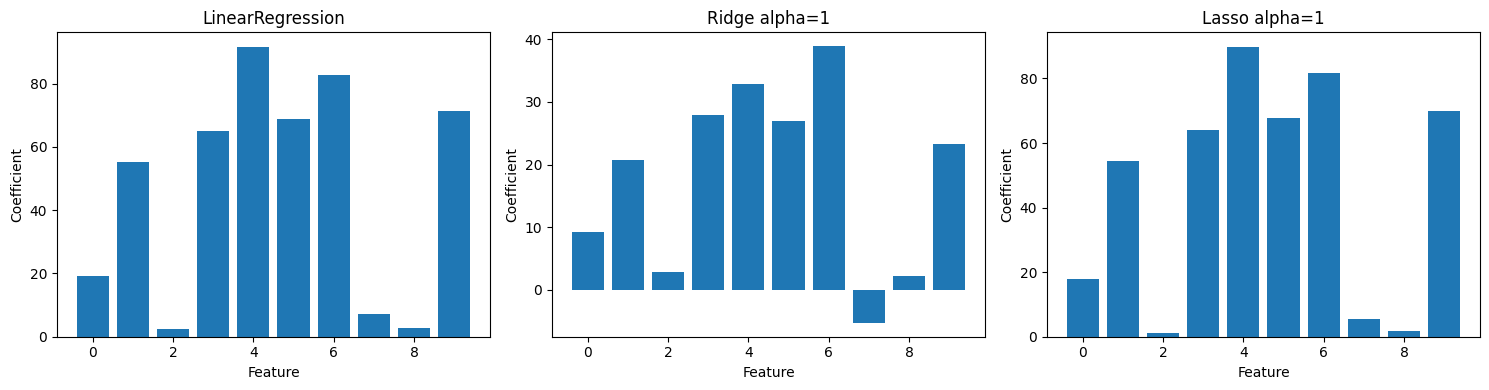

Ridge coefficient ছোট করে, Lasso কিছু 0 করে দেয়!


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models = [
    ('LinearRegression', lr_multi.coef_),
    ('Ridge alpha=1', ridge.coef_),
    ('Lasso alpha=1', lasso.coef_)
]
for i, (name, coefs) in enumerate(models):
    axes[i].bar(range(len(coefs)), coefs)
    axes[i].set_title(name)
    axes[i].set_xlabel('Feature')
    axes[i].set_ylabel('Coefficient')
plt.tight_layout()
plt.show()
print('Ridge coefficient ছোট করে, Lasso কিছু 0 করে দেয়!')

## সারসংক্ষেপ

| মডেল | নিয়মিতকরণ | বৈশিষ্ট্য |
|-------|------------|----------|
| LinearRegression | নেই | overfit করতে পারে, বড় ডেটায় ধীর |
| Ridge | L2 (alpha) | সব coefficients ছোট করে, অধিকাংশ ক্ষেত্রে সেরা |
| Lasso | L1 (alpha) | কিছু coefficient 0 করে, feature selection-এ ভালো |